In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.linalg import lu_factor, lu_solve
from scipy.sparse.linalg import LinearOperator, lsqr
import scipy
import time
from scipy.interpolate import lagrange, RegularGridInterpolator
from ader_dg_transport.utils import gll, lagrange1st

from ader_dg_transport.dg_2D import wave_dg_2D, wave_dg_adjoint_2D, wave_dg_optimizer_receiver_2D

import importlib
import os
os.environ["OMP_NUM_THREADS"] = "1"
import scipy.io as sio

In [2]:
data = sio.loadmat('Marmousi_vel.mat')['Marvel']

marmousi = np.copy(data[:, 600:1200])
marmousi[marmousi < 1500] = 1500
xs_ = np.linspace(0, 9_200, data.shape[1])[:marmousi.shape[1]]
xs_ -= xs_.min()
ys_ = np.linspace(0, 3_000, data.shape[0])

interp = RegularGridInterpolator((ys_, xs_), marmousi, method='nearest')

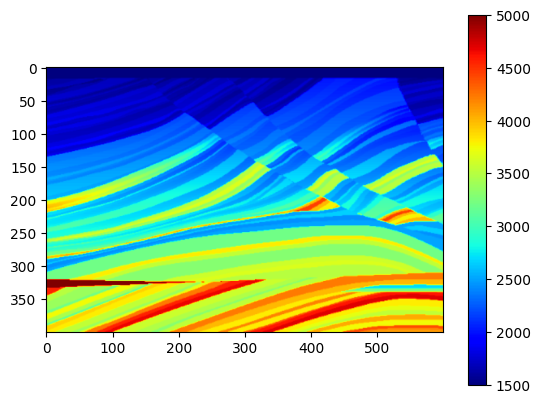

In [3]:
plt.imshow(marmousi, cmap='jet')
plt.colorbar()

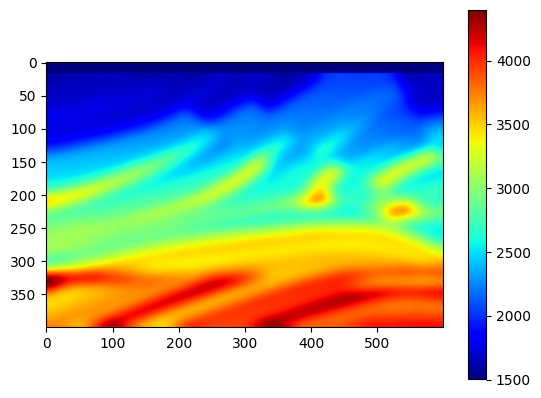

In [4]:
idx = np.where(marmousi[:, 0] > marmousi.min())[0][0]
semi_smooth_marmousi = np.copy(marmousi)
semi_smooth_marmousi[idx:] = scipy.ndimage.gaussian_filter(marmousi[idx:], sigma=10)

semi_smooth_interp = RegularGridInterpolator((ys_, xs_), semi_smooth_marmousi, method='nearest')
plt.imshow(semi_smooth_marmousi, cmap='jet')
plt.colorbar()

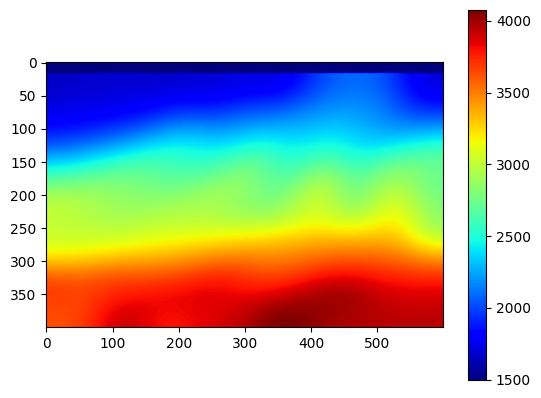

In [5]:
idx = np.where(marmousi[:, 0] > marmousi.min())[0][0]
smooth_marmousi = np.copy(marmousi)
smooth_marmousi[idx:] = scipy.ndimage.gaussian_filter(marmousi[idx:], sigma=30)

smooth_interp = RegularGridInterpolator((ys_, xs_), smooth_marmousi, method='nearest')
plt.imshow(smooth_marmousi, cmap='jet')
plt.colorbar()

In [101]:
xlim = xs_.max()
ylim = ys_.max()


ny = 10
# nx = 1 * ny
nx = 10
c = marmousi.max()

poly_order = 3

dx = xlim / nx
dy = ylim / ny
cfl = 1. / (2 * poly_order + 1)
dt = cfl * min(dx, dy) / c

tend = 6.0

nsteps = int(tend / dt) + 1
dt = tend / nsteps

In [102]:
dy / 3, dx / 3

(np.float64(100.0), np.float64(108.11850107906612))

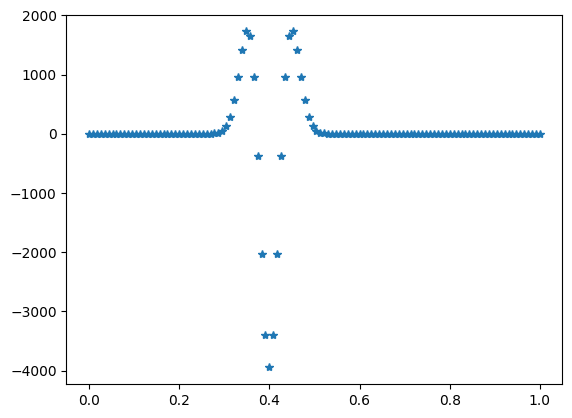

In [103]:
sig = 0.5 * xlim / nx
f0 = 10
def F(t_in, f0):
    t = t_in - 0.3
    return (2 * np.pi * f0)**2 * ((4 * np.pi * (f0 * t - 1)**2) - 1) * np.exp(-2 * np.pi * (f0 * t - 1)**2)


def f(x, y, t, f0, xc):

    
    out = np.zeros(t.shape + (3,) + x.shape)

    out[:, 1] = F(t, f0)[:, None, None, None, None] * np.exp(-((x - xc)**2 + (y - 0.9 * ylim)**2) / (2 * sig**2))[None]
    return out



# ts = np.linspace(0, 3 / f0, 100)
# forcing = f(xs, 3, ts)

# ts = np.linspace(0, 3 / f0, 100)
# plt.plot(ts * f0, F(ts))

ts = np.linspace(0, 1, int(1 / dt))
plt.plot(ts, F(ts, f0=f0), '*')

# plt.figure()
# plt.tricontourf(xs.ravel(), ys.ravel(), f(xs - 1000, ys, np.array([1 / f0]), f0=2.5)[0, 1].ravel())

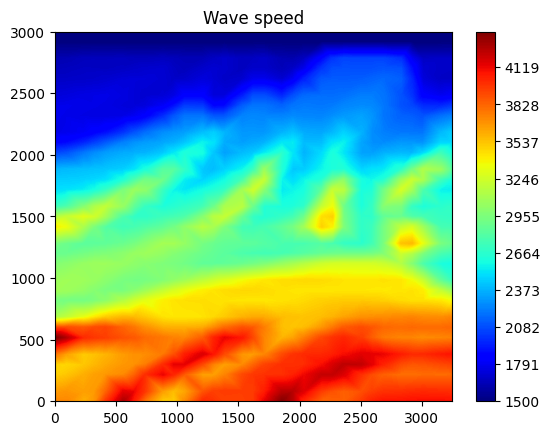

In [104]:
importlib.reload(wave_dg_2D)
importlib.reload(wave_dg_adjoint_2D)

forward_solver = wave_dg_2D.WaveDG2D(xlim, ylim, nx, ny, poly_order=poly_order, c=c, dt=dt)
forward_solver.y_periodic = False
forward_solver.x_periodic = False

adjoint_solver = wave_dg_adjoint_2D.WaveAdjointDG2D(xlim, ylim, nx, ny, poly_order=poly_order, c=c, dt=dt)
adjoint_solver.y_periodic = forward_solver.y_periodic
adjoint_solver.x_periodic = forward_solver.x_periodic

xs = forward_solver.xs
ys = forward_solver.ys

pts = np.vstack([ylim - ys.ravel(), xs.ravel()]).transpose()
# c_exact = interp(pts).reshape(forward_solver.c.shape)

c_exact = semi_smooth_interp(pts).reshape(forward_solver.c.shape)

r2 = (xs - (xlim / 2))**2 + (ys - 0.8 * ylim)**2
h0 = np.exp(-r2 / 500**2)

# # forward_solver.c[forward_solver.xs > 5] = 0.5
forward_solver.c[:] = c_exact
adjoint_solver.c[:] = forward_solver.c

plt.title(f'Wave speed')
plt.tricontourf(xs.ravel(), ys.ravel(), c_exact.ravel(), levels=1000, cmap='jet')
plt.colorbar()

## Get target state

## Optimize

In [105]:
from functools import partial

dxs = [-1000, -500, 0.0, 500, 1000]
freqs = [2.5, 5.0, 7.5, 10.0]

forcing_funcs_dict = dict()
for f0 in freqs:
    forcing_funcs_dict[f0] = []
    for dx in dxs:
        xc = 0.5*xlim+dx
        forcing_funcs_dict[f0].append(partial(f, f0=f0, xc=xc))

In [106]:
target_data_dict = dict()
for f0 in freqs:
    target_data_dict[f0] = [np.zeros((nsteps, 3, nx, poly_order + 1)) for _ in forcing_funcs_dict[f0]]

    for data, forcing_func in zip(target_data_dict[f0], forcing_funcs_dict[f0]):
        forward_solver.c[:] = c_exact
        forward_solver.time = 0.0
        forward_solver.state[:] = 0.0
        
        for i in range(nsteps):
        
            ts = np.array([forward_solver.time] * 4)
            ts[1] += 0.5 * dt
            ts[2] += dt
            ts[3] += 0.5 * dt
            
            forward_solver.time_step(forcing=forcing_func(xs, ys, ts))
            # forward_solver.time_step()
        
            data[i][:] = forward_solver.state[(slice(None),) + forward_solver.ym_ext]

In [107]:
ts = np.arange(1, nsteps + 1) * dt
t_mute = 3.0
tw = np.clip((ts - t_mute)/0.2, 0, 1)

In [108]:
optimizers_dict = dict()
ic_state = np.zeros_like(forward_solver.state)
for f0 in freqs:
    optimizers_dict[f0] = [wave_dg_optimizer_receiver_2D.WaveDGOptimizerReceiver2D(
        forward_solver, adjoint_solver, ic_state=ic_state, target_data=data, nsteps=nsteps, forcing_func=f, tw=None
    ) for f, data in zip(forcing_funcs_dict[f0], target_data_dict[f0])]

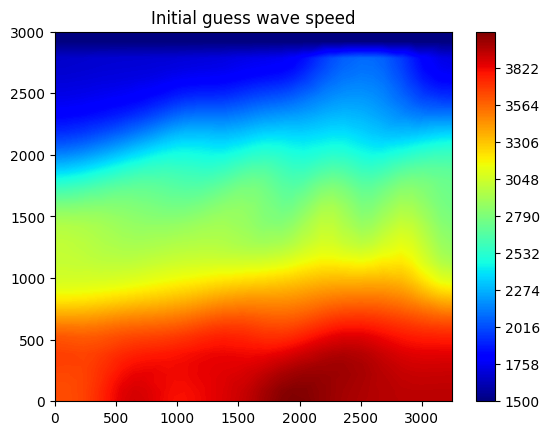

In [109]:
# c0 = np.ones_like(c_true)
# c0 = c_true.mean(axis=(0, 2), keepdims=True) * np.ones_like(np.ones_like(c_true))
c0 = smooth_interp(pts).reshape(forward_solver.c.shape)
# c0 = 1500 - (ys - 3500) * 0.6
c0_w = c0 * optimizers_dict[freqs[0]][0].M_half

plt.title(f'Initial guess wave speed')
plt.tricontourf(xs.ravel(), ys.ravel(), c0.ravel(), levels=1000, cmap='jet')
plt.colorbar()

In [110]:
c_water = c_exact.min()
water_mask = (c_exact < c_water)

In [111]:
def fix_wavespeed(c_in):
    c_shape = optimizers[0].forward_solver.c.shape
    c_out = np.copy(c_in.reshape(c_shape))
    c_out[water_mask] = c_water

    return c_out.reshape(c_in.shape)


def fix_wavespeed_w(c_w_in):
    c_shape = optimizers[0].forward_solver.c.shape
    c_in = optimizers[0].M_half_inv * c_w_in.reshape(c_shape)
    c_out = fix_wavespeed(c_in)

    c_w_out = c_out * optimizers[0].M_half

    return c_w_out.reshape(c_w_in.shape)

In [114]:
mu = 0.0


def cost_function_w(c_w_in, optimizers=optimizers):
    c_w_in = fix_wavespeed_w(c_w_in)
    penalty = (c_w_in**2).sum()
    return sum(optimizer.cost_function_w(c_w_in) for optimizer in optimizers) + 0.5 * mu * penalty


def jac_function_w(c_w_in, optimizers=optimizers):
    c_w_in = fix_wavespeed_w(c_w_in)
    out = sum(optimizer.jac_function_w(c_w_in) for optimizer in optimizers) + mu * c_w_in.ravel()

    c_shape = optimizers[0].forward_solver.c.shape
    out = out.reshape(c_shape)
    out[water_mask] = 0.0
    return out.ravel() 

In [115]:
c_est = np.copy(c0)

c_hist = [np.copy(c_est)]

for f0 in freqs:

    print(f'Running freq {f0}')

    # setup cost functions
    optimizers = optimizers_dict[f0]
    cost_function_w_hf = lambda c: cost_function_w(c, optimizers=optimizers)
    jac_function_w_hf = lambda c: jac_function_w(c, optimizers=optimizers)

    # report initial error
    c_est_w = c_est * optimizers[0].M_half
    c_error = c_est - c_exact
    
    print('Initial wave speed (c) RMSE:', np.sqrt(0.5 * (c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')
    print('Initial target function:', cost_function_w_hf(c_est_w))

    # optimizer
    options = {
        'maxiter': 20,
        'ftol': 1e-8,
        'gtol': 1e-6,
        'maxcor': 5
    }
    
    result = scipy.optimize.minimize(
        cost_function_w, c_est_w.ravel(), jac=jac_function_w, method='L-BFGS-B', options=options
    )
    
    c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].M_half_inv
    c_est_w = c_est * optimizers[0].M_half
    c_error = c_est - c_exact

    print('Final wave speed (c) RMSE:', np.sqrt(0.5 * (c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')
    print('Final target function:', cost_function_w_hf(c_est_w))
    
    c_hist.append(np.copy(c_est))
    
    print()

Running freq 2.5
Initial wave speed (c) RMSE: 99.17096349399567 m/s
Initial target function: 295757.9102875781
Final wave speed (c) RMSE: 93.59200643258 m/s
Final target function: 8811.543129303138

Running freq 5.0
Initial wave speed (c) RMSE: 93.59200643258 m/s
Initial target function: 23405.55374355027
Final wave speed (c) RMSE: 87.60346334890848 m/s
Final target function: 9687.8508636093

Running freq 7.5
Initial wave speed (c) RMSE: 87.60346334890848 m/s
Initial target function: 8653.862248146734
Final wave speed (c) RMSE: 85.18792132715319 m/s
Final target function: 5601.647962545845

Running freq 10.0
Initial wave speed (c) RMSE: 85.18792132715319 m/s
Initial target function: 4193.22605748914
Final wave speed (c) RMSE: 82.86591885690626 m/s
Final target function: 3061.571848396926



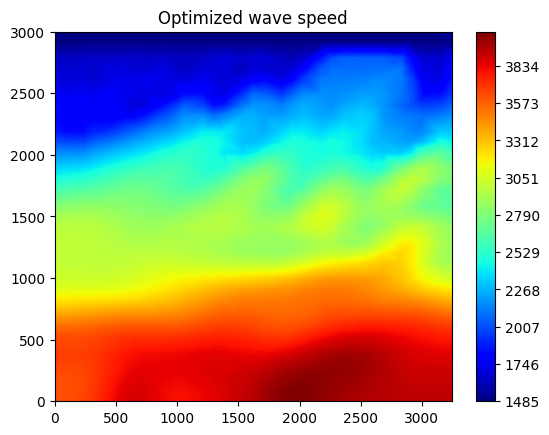

In [125]:
plt.title(f'Optimized wave speed')
plt.tricontourf(xs.ravel(), ys.ravel(), c_hist[4].ravel(), levels=1000, cmap='jet')
plt.colorbar()

In [ ]:
for f0 in freqs:

    print(f'Running freq {f0}')

    # setup cost functions
    optimizers = optimizers_dict[f0]
    cost_function_w_hf = lambda c: cost_function_w(c, optimizers=optimizers)
    jac_function_w_hf = lambda c: jac_function_w(c, optimizers=optimizers)

    # report initial error
    c_est_w = c_est * optimizers[0].M_half
    c_error = c_est - c_exact
    
    print('Initial wave speed (c) RMSE:', np.sqrt(0.5 * (c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')
    print('Initial target function:', cost_function_w_hf(c_est_w))

    # optimizer
    options = {
        'maxiter': 50,
        'ftol': 1e-8,
        'gtol': 1e-6,
        'maxcor': 5
    }
    
    result = scipy.optimize.minimize(
        cost_function_w, c_est_w.ravel(), jac=jac_function_w, method='L-BFGS-B', options=options
    )
    
    c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].M_half_inv
    c_est_w = c_est * optimizers[0].M_half
    c_error = c_est - c_exact

    print('Final wave speed (c) RMSE:', np.sqrt(0.5 * (c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')
    print('Final target function:', cost_function_w_hf(c_est_w))
    
    c_hist.append(np.copy(c_est))
    
    print()

Running freq 2.5
Initial wave speed (c) RMSE: 82.86591885690626 m/s
Initial target function: 1964.8724025969664
